In [1]:
from src import Color
from typing import Tuple, List
from src.io.image_helper import image_to_ppm, convert_ppm_to_png, ipynb_display_images
from src.io.image_helper import image_pipeline, ipnb_display_multiple_images_in_row
from src.visualizer import Visualizer
from dataclasses import field, dataclass
from src import Vector, Vertex

## About this series of notebooks

This series of notebooks introduces the fundamental principles of ray tracing through a step-by-step implementation of a simple ray tracer built from scratch. The goal is not only to produce images, but to understand the mathematical and computational ideas behind modern rendering techniques.

Throughout the series, we will gradually develop a ray tracer while exploring key concepts, including:

- Color representation and image generation
- Coordinate systems and geometric foundations
- Ray generation and camera models
- Ray–object intersection algorithms
- Shading and lighting models
- Reflection and refraction
- Acceleration structures for performance
- Noise functions and procedural textures
- Additional extensions and experiments

The notebooks are designed to be **hands-on and exploratory**. Each topic combines theory, visual explanations, and practical implementation exercises to help build intuition about how ray tracing works internally.

All examples are implemented in **Python**, using:

- **NumPy** for mathematical operations
- **Pillow** for image output
- A custom educational ray tracing framework providing core rendering and scene management functionality

By the end of this series, you will understand how a ray tracer operates from first principles and will be able to extend or build your own rendering system.

> The emphasis of this series is clarity and conceptual understanding rather than rendering performance or photorealism.

Let’s get started.

## Before we dive into ray tracing

Before implementing the ray tracer itself, we first need a few basic data structures that will be used throughout the entire series.

One of the most important structures is the **image representation**.
A rendered image can be viewed as a collection of pixels, where each pixel stores a color value. For simplicity and educational clarity, we will represent an image as:

- a list of pixel colors,
- the image width,
- and the image height.

This minimal representation allows us to focus on ray tracing concepts without introducing unnecessary complexity from external image frameworks.

### Image representation

In [2]:
Image = Tuple[List[Color], int, int]
black = Color.linear_rgb(0.0, 0.0, 0.0)

def create_empty_image(width: int, height: int) -> Image:
    """
    Creates an empty image filled with black color. The image is represented as a tuple containing a list of pixel colors,
    the width, and the height. Each pixel color is initialized to black (0.0, 0.0, 0.0 in linear RGB).
    :param width: The width of the image in pixels
    :param height: The height of the image in pixels
    :return: Image - a tuple containing the list of pixel colors, width, and height
    """
    pixels = [black for _ in range(width * height)]
    return pixels, width, height

## Creating and saving our first image

With the basic image structure defined, we can now create an empty image and save it to disk to verify that our image creation pipeline works correctly.

In this step, we will:

1. Create a black image with a resolution of **500 × 500 pixels**.
2. Save it as a **PPM file**, a simple text-based image format that stores pixel values directly.
3. Convert the image to **PNG** format for convenient viewing.
4. Display the result inside the notebook.

This small test confirms that image creation, file output, and visualization are functioning before we begin rendering with rays.


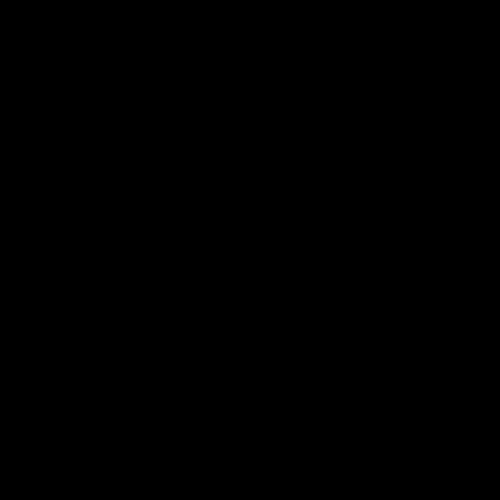

In [3]:
image = create_empty_image(500, 500)

image_to_ppm("black_image.ppm", image)
convert_ppm_to_png("black_image.ppm", "black_image.png")
ipynb_display_images("black_image.png")

## Color representation

Colors in our renderer are represented in **linear RGB space**, where each channel — red, green, and blue — is stored as a floating-point value in the range **0.0 to 1.0**.

Using linear RGB is important because it enables physically meaningful color computations, such as lighting calculations, blending, and shading operations. Performing these operations directly in non-linear (gamma-encoded) color spaces would produce incorrect results.

The `Color` class provides several convenient ways to construct colors:

- `linear_rgb(r, g, b)` — create a color directly from linear RGB values
- `custom_rgb(r, g, b)` — create a color from standard 8-bit RGB values (0–255), automatically converted to linear space

This design makes it easy to work with both mathematically correct color values and familiar RGB color definitions when creating scenes.

![image](./edu_src/color.png)

## Setting pixel colors as a gradient

Now that we have a basic image representation, we can assign colors to individual pixels.
As a first experiment, we will generate a simple **color gradient** to verify that pixel addressing works correctly.

The gradient encodes spatial information into color channels:

- the **X axis** controls the **red** channel,
- the **Y axis** controls the **green** channel,
- the **blue** channel can be varied across layers to simulate depth (for now it will remain constant).

This visualization helps us confirm that pixel coordinates are mapped correctly inside the image buffer.

In [4]:
def set_pixel_color(image: Image, x: int, y: int, color: Color) -> None:
    """
    Sets the color of a specific pixel in the image. The (x, y) coordinates specify the pixel's position,
    and the color is a tuple representing the RGB values. The function checks if the coordinates are within the bounds of the image before setting the pixel color.
    :param image: The image represented as a tuple of (pixels, width, height)
    :param x: pixel's x-coordinate (horizontal position)
    :param y: pixel's y-coordinate (vertical position)
    :param color: color to set for the specified pixel, represented as a tuple of (R, G, B) values
    :return: None
    """
    pixels, width, height = image
    if 0 <= x < width and 0 <= y < height:
        pixels[y * width + x] = color

### Setting a pixel color

In [5]:
images = []
image = create_empty_image(50, 50)

for z in range(50):
    for x in range(50):
        for y in range(50):
                r = x / 49.0
                g = y / 49.0
                b = z / 49.0
                set_pixel_color(image, x, y, Color.linear_rgb(r, g, b))
    images.append(image_pipeline(image, z))

ipnb_display_multiple_images_in_row(images, row_size=10)

## Coordinate system visualization

Throughout this series, we will use a **right-handed coordinate system**, defined as follows:

- The **X-axis** points to the right
- The **Y-axis** points upward
- The **Z-axis** points toward the viewer (out of the screen)
- The origin **(0, 0, 0)** is located at the center of the scene

Understanding the coordinate system is essential for ray tracing, since camera rays, object positions, and lighting calculations all operate in 3D space.

### Visualizing the coordinate system

To better understand spatial relationships, we will use a custom `Visualizer` class that renders simple 3D scenes using **Matplotlib**. This allows us to inspect scenes from a third-person perspective and observe how objects and rays are positioned in space.

We begin by creating an empty scene containing a grid and coordinate axes. This visualization will serve as a reference throughout the notebook series.

The appearance of the scene can be customized via the `create_empty_scene` function parameters.

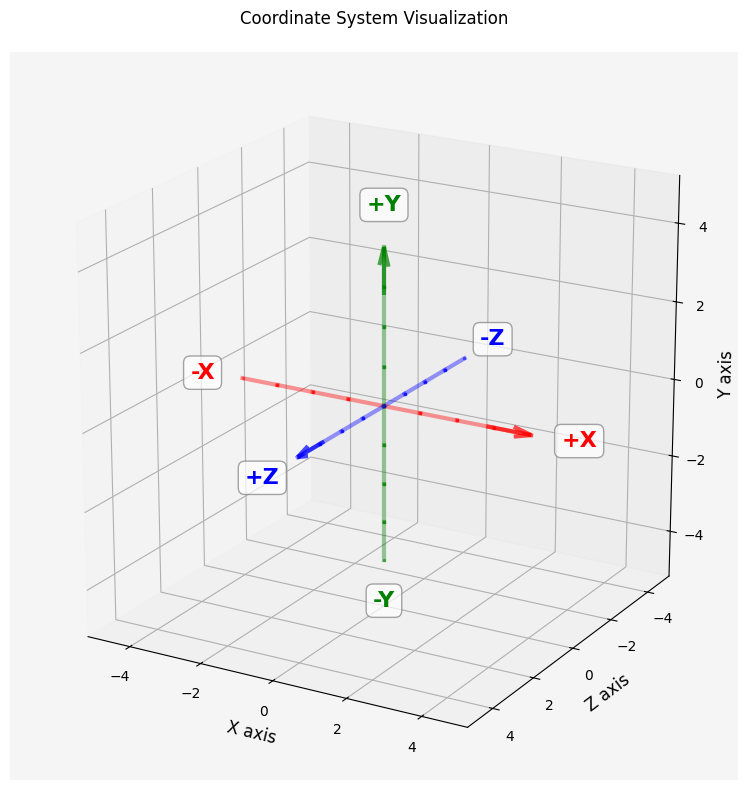

In [6]:
vis = Visualizer()
vis.create_empty_scene(
    size=4.0,
    figsize=(12, 8),
    show_axes_labels=True,
    show_arrows=True,
    show_grid=True,
    show_axes=True,
    show_xyz_labels=True
)
vis.set_title("Coordinate System Visualization")
vis.savefig("empty.png")
vis.show()

---

# Ray tracing fundamentals

Ray tracing is a rendering technique that simulates how light interacts with objects in a scene to produce an image. Instead of drawing objects directly onto the screen, the algorithm traces **rays** through a virtual 3D environment and computes the color of each pixel based on lighting and material interactions.

In its simplest form, ray tracing works by casting rays from the camera into the scene and determining which objects they intersect.

---

## Pinhole camera model

A **pinhole camera** can be imagined as a small box with a tiny opening. All incoming light passes through this single point before reaching the image surface. This simple physical model forms the foundation of many rendering systems.

In computer graphics, the pinhole camera is described using:

- a **camera position** (the pinhole),
- a **view direction**,
- an **image plane** placed in front of the camera.

Each pixel of the final image corresponds to a specific point on this image plane.

### Ray generation

To generate a viewing ray:

1. Select a point on the image plane corresponding to a pixel.
2. Compute the direction from the camera position toward that point.
3. Create a ray starting at the camera and traveling along this direction.

`R(t) = O + tD`
  - `O` is the ray origin (camera position)
  - `D` is the ray direction (normalized vector from camera to pixel on image plane)
  - `t` is a parameter that determines how far along the ray we are

For simplicity, the image plane is positioned **one unit in front of the camera**, which keeps the mathematics straightforward while preserving correct perspective projection.

In [7]:
from src.geometry.ray import Ray
from math import radians, tan


@dataclass
class Camera:
    """
    Simple pinhole camera model with position, direction, up vector and field of view. The camera generates rays for each pixel on the image plane based on its orientation and FOV.
    """
    fov_deg: float = 70.0
    aspect_ratio: float = 16.0 / 9.0
    origin: Vertex = field(default_factory=lambda: Vertex(0, 0, 0))
    direction: Vector = field(default_factory=lambda: Vector(0, 0, -1))
    up_hint: Vector = field(default_factory=lambda: Vector(0, 1, 0))

    forward: Vector = field(init=False)
    right: Vector = field(init=False)
    up: Vector = field(init=False)

    half_width: float = field(init=False)
    half_height: float = field(init=False)

    def __post_init__(self):
        self.update_camera()

    def update_camera(self):
        """
            Calculate camera basis vectors and image plane dimensions.
            :return: None
        """
        forward = self.direction.normalize()
        up = self.up_hint
        # if direction is parallel to up_hint, choose a different up vector
        if abs(forward.dot(up)) > 0.999:
            up = Vector(1, 0, 0)

        # build orthonormal basis
        w = -forward
        right = up.cross(w).normalize()
        true_up = w.cross(right)

        # calculate image plane dimensions based on FOV and aspect ratio
        theta = radians(self.fov_deg)
        half_height = tan(theta * 0.5)
        half_width = self.aspect_ratio * half_height

        self.forward = forward
        self.right = right
        self.up = true_up
        self.half_width = half_width
        self.half_height = half_height

    def make_ray(self, u: float, v: float) -> Ray:
        """
        u, v in [-1, 1]
        (-1,-1)=bottom-left, (1,1)=top-right
        Image plane is 1 unit in front of the camera.
        """
        center_plane = self.origin + self.forward

        position = (
                center_plane
                + self.right * (u * self.half_width)
                + self.up * (v * self.half_height)
        )
        return Ray(self.origin, (position - self.origin).normalize())

    def set_aspect_ratio(self, aspect_ratio: float):
        self.aspect_ratio = aspect_ratio
        self.update_camera()